In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.insert(0, '..')  # so we can import from src/

from src.config import RAW_LOANS_CSV, TARGET_COL
print("Libraries loaded OK")


Libraries loaded OK


In [2]:
df = pd.read_csv('../data/raw/loans.csv', low_memory=False)
print(df.shape)
print(df['loan_status'].value_counts())


(2260701, 151)
loan_status
Fully Paid                                             1076751
Current                                                 878317
Charged Off                                             268559
Late (31-120 days)                                       21467
In Grace Period                                           8436
Late (16-30 days)                                         4349
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     40
Name: count, dtype: int64


In [3]:
import os
os.getcwd()


'/Users/amith/Desktop/credit-risk/notebooks'

In [4]:
df = pd.read_csv('data/raw/loans.csv', low_memory=False)
print(df.shape)
print(df['loan_status'].value_counts())

FileNotFoundError: [Errno 2] No such file or directory: 'data/raw/loans.csv'

In [5]:
resolved_bad = {'Charged Off', 'Default', 
                'Does not meet the credit policy. Status:Charged Off'}
resolved_good = {'Fully Paid', 
                 'Does not meet the credit policy. Status:Fully Paid'}

df = df[df['loan_status'].isin(resolved_bad | resolved_good)].copy()
df['default'] = df['loan_status'].isin(resolved_bad).astype(int)

print(df.shape)
print(df['default'].value_counts())
print(f"\nDefault rate: {df['default'].mean():.1%}")


(1348099, 152)
default
0    1078739
1     269360
Name: count, dtype: int64

Default rate: 20.0%


In [6]:
# Drop post-origination leakage columns (known only AFTER loan plays out)
leakage_cols = [
    'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp',
    'total_rec_int', 'total_rec_late_fee', 'recoveries',
    'collection_recovery_fee', 'last_pymnt_d', 'last_pymnt_amnt',
    'next_pymnt_d', 'out_prncp', 'out_prncp_inv', 'loan_status'
]
df = df.drop(columns=[c for c in leakage_cols if c in df.columns])

print(f"Columns remaining: {df.shape[1]}")
print(df.dtypes.value_counts())

Columns remaining: 139
float64    103
object      35
int64        1
Name: count, dtype: int64


In [7]:
missing = df.isnull().mean().sort_values(ascending=False)
missing = missing[missing > 0]
print(f"Columns with missing values: {len(missing)}")
print(missing.head(20))


Columns with missing values: 111
member_id                                     1.000000
orig_projected_additional_accrued_interest    0.997210
hardship_end_date                             0.995730
payment_plan_start_date                       0.995730
hardship_length                               0.995730
hardship_dpd                                  0.995730
hardship_loan_status                          0.995730
hardship_payoff_balance_amount                0.995730
hardship_last_payment_amount                  0.995730
hardship_start_date                           0.995730
hardship_amount                               0.995730
deferral_term                                 0.995730
hardship_status                               0.995730
hardship_reason                               0.995730
hardship_type                                 0.995730
sec_app_mths_since_last_major_derog           0.995068
sec_app_revol_util                            0.986419
revol_bal_joint                 

In [8]:
# Drop columns >40% missing
high_missing = missing[missing > 0.4].index.tolist()
df = df.drop(columns=high_missing)
print(f"Dropped {len(high_missing)} high-missing columns")
print(f"Columns remaining: {df.shape[1]}")

# Select core credit-relevant features
features = [
    'loan_amnt', 'term', 'int_rate', 'installment', 'grade',
    'emp_length', 'home_ownership', 'annual_inc', 'verification_status',
    'purpose', 'dti', 'delinq_2yrs', 'fico_range_low', 'fico_range_high',
    'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util',
    'total_acc', 'mort_acc', 'pub_rec_bankruptcies', 'default'
]

df = df[[c for c in features if c in df.columns]]
print(f"\nFinal columns: {df.shape[1]}")
print(df.head(2))

Dropped 57 high-missing columns
Columns remaining: 82

Final columns: 23
   loan_amnt        term  int_rate  installment grade emp_length  \
0     3600.0   36 months     13.99       123.03     C  10+ years   
1    24700.0   36 months     11.99       820.28     C  10+ years   

  home_ownership  annual_inc verification_status             purpose  ...  \
0       MORTGAGE     55000.0        Not Verified  debt_consolidation  ...   
1       MORTGAGE     65000.0        Not Verified      small_business  ...   

   fico_range_high  inq_last_6mths  open_acc  pub_rec  revol_bal  revol_util  \
0            679.0             1.0       7.0      0.0     2765.0        29.7   
1            719.0             4.0      22.0      0.0    21470.0        19.2   

   total_acc  mort_acc  pub_rec_bankruptcies  default  
0       13.0       1.0                   0.0        0  
1       38.0       4.0                   0.0        0  

[2 rows x 23 columns]


FileNotFoundError: [Errno 2] No such file or directory: '/Users/amith/Desktop/credit-risk/notebooks/reports/figures/eda_overview.png'

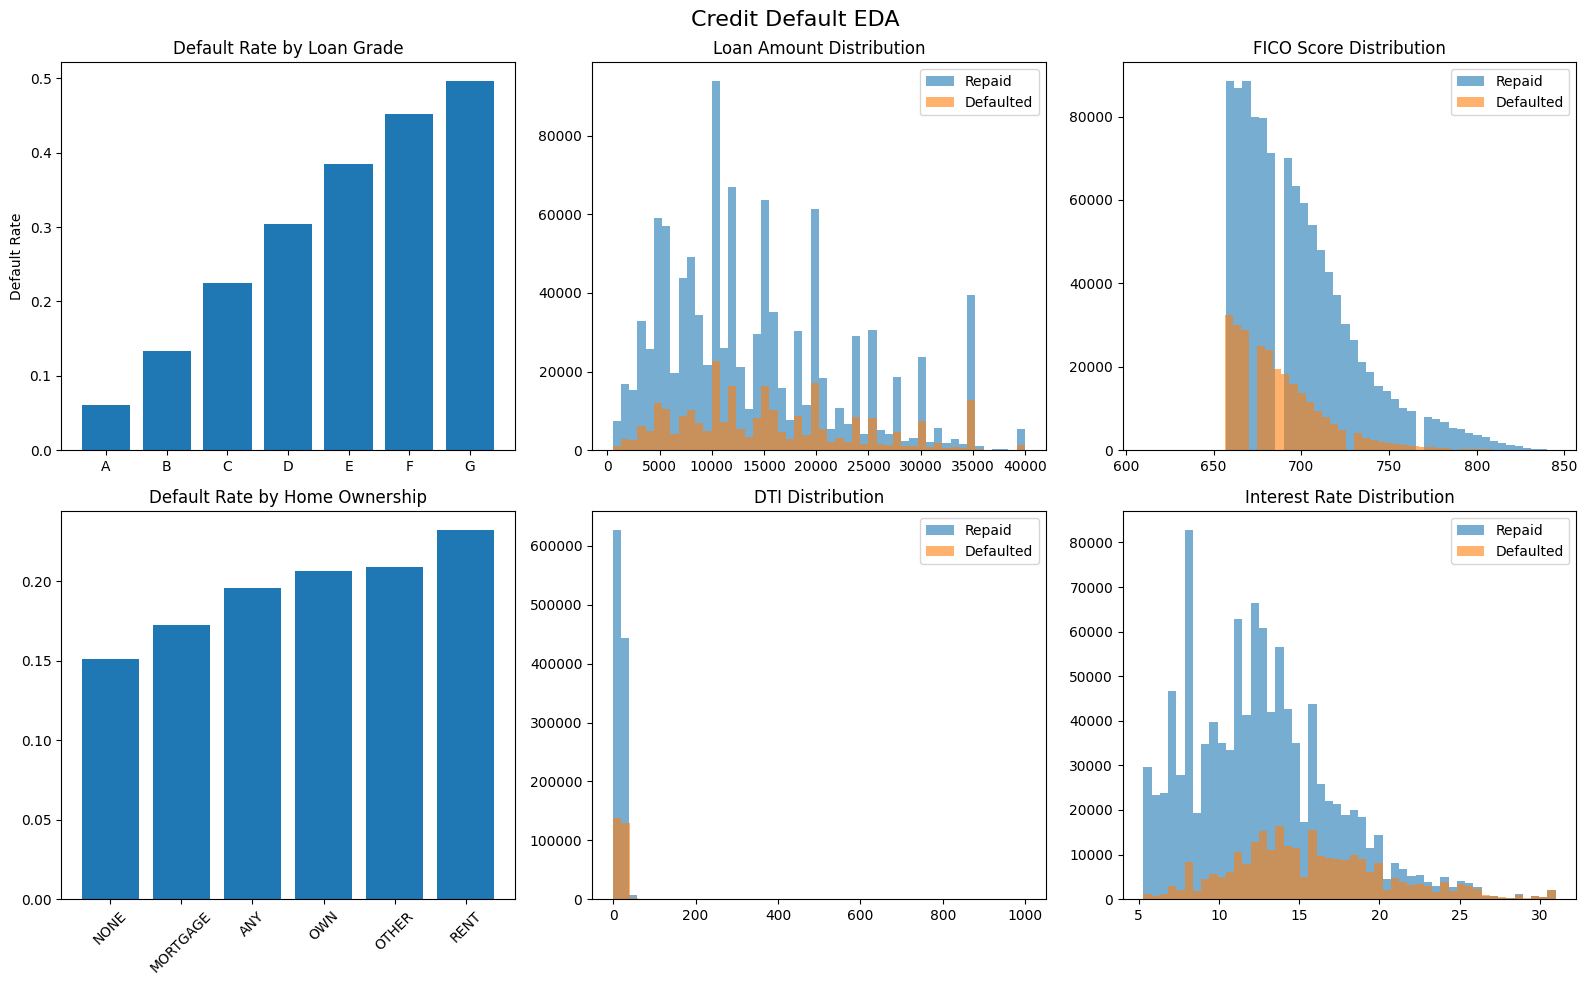

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Credit Default EDA', fontsize=16)

# 1. Default rate by grade
default_by_grade = df.groupby('grade')['default'].mean().sort_index()
axes[0,0].bar(default_by_grade.index, default_by_grade.values)
axes[0,0].set_title('Default Rate by Loan Grade')
axes[0,0].set_ylabel('Default Rate')

# 2. Loan amount distribution
axes[0,1].hist(df[df['default']==0]['loan_amnt'], bins=50, alpha=0.6, label='Repaid')
axes[0,1].hist(df[df['default']==1]['loan_amnt'], bins=50, alpha=0.6, label='Defaulted')
axes[0,1].set_title('Loan Amount Distribution')
axes[0,1].legend()

# 3. FICO score distribution
axes[0,2].hist(df[df['default']==0]['fico_range_low'], bins=50, alpha=0.6, label='Repaid')
axes[0,2].hist(df[df['default']==1]['fico_range_low'], bins=50, alpha=0.6, label='Defaulted')
axes[0,2].set_title('FICO Score Distribution')
axes[0,2].legend()

# 4. Default rate by home ownership
default_by_home = df.groupby('home_ownership')['default'].mean().sort_values()
axes[1,0].bar(default_by_home.index, default_by_home.values)
axes[1,0].set_title('Default Rate by Home Ownership')
axes[1,0].tick_params(axis='x', rotation=45)

# 5. DTI distribution
axes[1,1].hist(df[df['default']==0]['dti'], bins=50, alpha=0.6, label='Repaid')
axes[1,1].hist(df[df['default']==1]['dti'], bins=50, alpha=0.6, label='Defaulted')
axes[1,1].set_title('DTI Distribution')
axes[1,1].legend()

# 6. Interest rate by default
axes[1,2].hist(df[df['default']==0]['int_rate'], bins=50, alpha=0.6, label='Repaid')
axes[1,2].hist(df[df['default']==1]['int_rate'], bins=50, alpha=0.6, label='Defaulted')
axes[1,2].set_title('Interest Rate Distribution')
axes[1,2].legend()

plt.tight_layout()
plt.savefig('reports/figures/eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to reports/figures/eda_overview.png")

In [10]:
# Clean dtypes
df['term'] = df['term'].str.strip().str.replace(' months', '').astype(int)
df['int_rate'] = df['int_rate'].astype(float)
df['revol_util'] = pd.to_numeric(df['revol_util'], errors='coerce')
df['emp_length'] = df['emp_length'].str.extract(r'(\d+)').astype(float)

# Fill missing numerics with median
num_cols = df.select_dtypes(include='number').columns.drop('default')
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Fill missing categoricals with mode
cat_cols = df.select_dtypes(include='object').columns
df[cat_cols] = df[cat_cols].fillna(df[cat_cols].mode().iloc[0])

print("Nulls remaining:", df.isnull().sum().sum())
print(df.dtypes)

Nulls remaining: 0
loan_amnt               float64
term                      int64
int_rate                float64
installment             float64
grade                    object
emp_length              float64
home_ownership           object
annual_inc              float64
verification_status      object
purpose                  object
dti                     float64
delinq_2yrs             float64
fico_range_low          float64
fico_range_high         float64
inq_last_6mths          float64
open_acc                float64
pub_rec                 float64
revol_bal               float64
revol_util              float64
total_acc               float64
mort_acc                float64
pub_rec_bankruptcies    float64
default                   int64
dtype: object


In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

X = df.drop(columns='default')
y = df['default']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Default rate train: {y_train.mean():.1%}, test: {y_test.mean():.1%}")

# Preprocessing pipeline
num_cols = X.select_dtypes(include='number').columns.tolist()
cat_cols = X.select_dtypes(include='object').columns.tolist()

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), cat_cols)
])


Train: (1078479, 22), Test: (269620, 22)
Default rate train: 20.0%, test: 20.0%


In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, classification_report
import joblib

models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(scale_pos_weight=4, random_state=42, eval_metric='logloss', n_jobs=-1)
}

results = {}
for name, model in models.items():
    print(f"Training {name}...")
    pipe = Pipeline([('pre', preprocessor), ('model', model)])
    pipe.fit(X_train, y_train)
    y_pred_proba = pipe.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_pred_proba)
    results[name] = {'pipe': pipe, 'auc': auc, 'proba': y_pred_proba}
    print(f"  ROC-AUC: {auc:.4f}")

print("\nDone!")

Training Logistic Regression...
  ROC-AUC: 0.7081
Training Random Forest...
  ROC-AUC: 0.7030
Training XGBoost...
  ROC-AUC: 0.7202

Done!


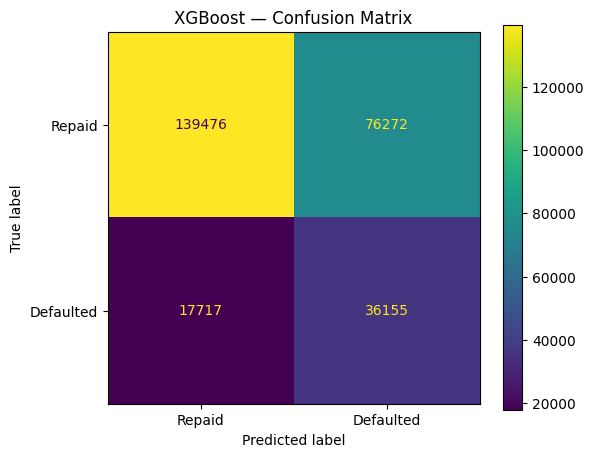

              precision    recall  f1-score   support

      Repaid       0.89      0.65      0.75    215748
   Defaulted       0.32      0.67      0.43     53872

    accuracy                           0.65    269620
   macro avg       0.60      0.66      0.59    269620
weighted avg       0.77      0.65      0.69    269620



In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

best_pipe = results['XGBoost']['pipe']
y_pred = best_pipe.predict(X_test)
y_proba = results['XGBoost']['proba']

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6,5))
ConfusionMatrixDisplay(cm, display_labels=['Repaid','Defaulted']).plot(ax=ax)
plt.title('XGBoost — Confusion Matrix')
plt.savefig('../reports/figures/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(classification_report(y_test, y_pred, target_names=['Repaid','Defaulted']))

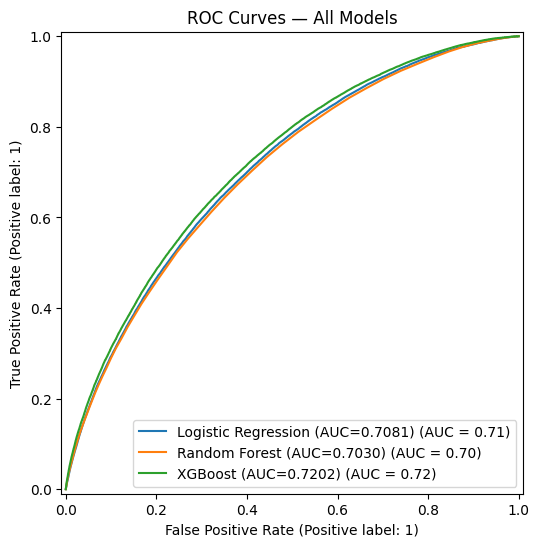

Model saved to models/credit_risk_model.joblib


In [14]:
from sklearn.metrics import RocCurveDisplay
import joblib, os

# Plot all 3 ROC curves together
fig, ax = plt.subplots(figsize=(8,6))
for name, res in results.items():
    RocCurveDisplay.from_predictions(
        y_test, res['proba'], name=f"{name} (AUC={res['auc']:.4f})", ax=ax)
ax.set_title('ROC Curves — All Models')
plt.savefig('../reports/figures/roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# Save best model
os.makedirs('../models', exist_ok=True)
joblib.dump(best_pipe, '../models/credit_risk_model.joblib')
print("Model saved to models/credit_risk_model.joblib")